# Análisis de la varianza molecular (AMOVA) 

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
from itertools import combinations, product
from collections import Counter
import random
from sklearn.metrics.pairwise import cosine_distances
import matplotlib.pyplot as plt
import seaborn as sns

## Funciones de ayuda

### Distancias

In [18]:
def hamming_distance(seq1, seq2):
    """
    Distancia de Hamming (modificacion de caracteres en cadenas de texto)
    """
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

def kmer_distance(seq1, seq2, k=4):
    """
    Distancia euclidiana entre vectores de frecuencia de k-meros.
    Tambien funciona para sequencias de diferente longitud
    """
    return np.linalg.norm(seq1 - seq2)

def compute_distance_matrix(X, metric='euclidean'):
    """
    Aplica la distancia entre cada 2 secuencias de una lista dada
    method: 'hamming' (requiere misma longitud) or 'kmer'
    """
    n = X.shape[0]
    D = np.zeros((n, n))
    if metric == 'euclidean':
        for i, j in combinations(range(n), 2):
            d = np.linalg.norm(X[i] - X[j])
            D[i, j] = D[j, i] = d
    elif metric == 'cosine':
        D = cosine_distances(X)
    elif metric == 'manhattan':
        for i, j in combinations(range(n), 2):
            d = np.sum(np.abs(X[i] - X[j]))
            D[i, j] = D[j, i] = d
    else:
        raise ValueError("metric must be 'euclidean', 'cosine', or 'manhattan'")
    return D


### AMOVA

In [19]:
def amova_from_distance_matrix(D, groups):
    """
    D : matriz de distancias (n_samples x n_samples)
    groups : lista de etiquetas de grupo (length n_samples)
    Returns dict with:
        'ss_total', 'ss_among', 'ss_within',
        'ms_among', 'ms_within',
        'var_among', 'var_within',
        'phi_st', 'p_value' (if permutations > 0)
    """
    groups = np.array(groups)
    unique_groups = groups # np.unique(groups)
    n = D.shape[0]
    
    D2 = D ** 2
    
    #  Escalamiento
    SS_total = np.sum(D2) / n
    
    # Suma de cuadrados en el grupo
    SS_within = 0.0
    for g in unique_groups:
        idx = np.where(groups == g)[0]
        n_g = len(idx)
        if n_g < 2:
            continue
        subD2 = D2[np.ix_(idx, idx)]
        SS_within += np.sum(subD2) / n_g
    SS_within = SS_within / 2  
    
    # Suma de cuadrados entre grupos
    SS_among = SS_total - SS_within
    
    # Grados de libertad
    df_total = n - 1
    df_among = len(unique_groups) - 1
    df_within = df_total - df_among
    
    # Promedio de cuadrados
    MS_among = SS_among / df_among if df_among > 0 else 0
    MS_within = SS_within / df_within if df_within > 0 else 0
    
    # Varianza
    n_i = [np.sum(groups == g) for g in unique_groups]
    n_prime = (n**2 - np.sum(np.array(n_i)**2)) / (df_among * n)
    var_among = (MS_among - MS_within) / n_prime if n_prime > 0 else 0
    var_within = MS_within
    
    # Phi-estadistico
    phi_st = var_among / (var_among + var_within) if (var_among + var_within) > 0 else 0
    
    return {
        'ss_total': SS_total,
        'ss_among': SS_among,
        'ss_within': SS_within,
        'df_among': df_among,
        'df_within': df_within,
        'ms_among': MS_among,
        'ms_within': MS_within,
        'var_among': var_among,
        'var_within': var_within,
        'phi_st': phi_st
    }

def permutation_test_amova(D, groups, n_permutations=999):
    """
    Aplica un test de permutacion para obtener la significancia de Phi_ST.
    """
    observed = amova_from_distance_matrix(D, groups)['phi_st']
    permuted_phis = []
    groups = np.array(groups)
    for _ in range(n_permutations):
        perm_groups = np.random.permutation(groups)
        perm_phi = amova_from_distance_matrix(D, perm_groups)['phi_st']
        permuted_phis.append(perm_phi)
    # p-value: proporcion de phi permutados >= observed
    p_value = (np.sum(np.array(permuted_phis) >= observed) + 1) / (n_permutations + 1)
    return p_value

In [20]:
def analisis(file="mc1r"):
    ids_df = pd.read_csv(f"../data/processed/{file}_encoded.csv") 
    df = pd.read_csv(f"../data/processed/{file}_4mers.csv")
    df['population'] = ids_df['id']
    #print(df.head())
    X = df.drop('population', axis=1).values.astype(float)
    groups = df['population'].values
    #print(groups)
    D = compute_distance_matrix(X)
    sns.heatmap(D)

    results = amova_from_distance_matrix(D, groups)
    p_val = permutation_test_amova(D, groups, n_permutations=999)
    results['p_value'] = p_val

    print(f"=== Resultados de AMOVA  ({file}) ===")
    for key, val in results.items():
        print(f"{key}: {val}")

## Aplicacion

=== Resultados de AMOVA  (mc1r) ===
ss_total: 0.0022354776023517505
ss_among: 0.0022354776023517505
ss_within: 0.0
df_among: 42
df_within: 0
ms_among: 5.3225657198851206e-05
ms_within: 0
var_among: 5.319620193753474e-05
var_within: 0
phi_st: 1.0
p_value: 1.0


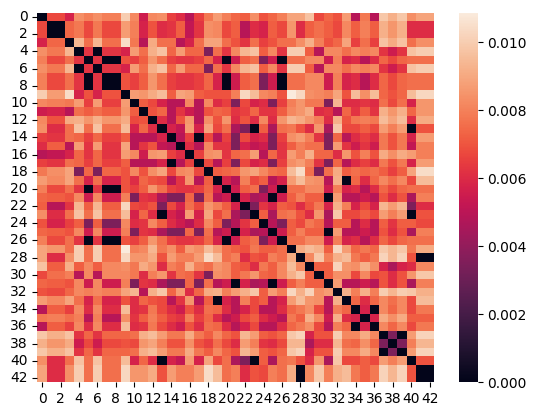

In [21]:
analisis("mc1r")

=== Resultados de AMOVA  (cytb) ===
ss_total: 0.0034016141120955163
ss_among: 0.0034016141120955163
ss_within: 0.0
df_among: 35
df_within: 0
ms_among: 9.718897463130046e-05
ms_within: 0
var_among: 9.711190169344852e-05
var_within: 0
phi_st: 1.0
p_value: 1.0


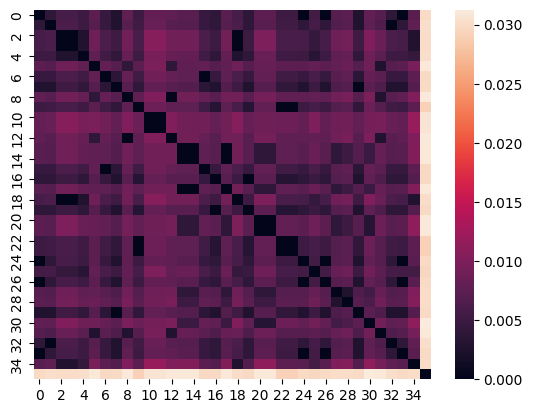

In [22]:
analisis("cytb")